# Use Case 4 — TKG Models: TNTComplEx vs TGN (Improved)

**Goal:** Compare two temporal graph learning approaches on the EPC dataset:

| Model | Task type | Why it fits |
|---|---|---|
| **TNTComplEx** | Temporal KG link prediction | Data is a structured TKG with typed relations + bitemporal timestamps |
| **TGN (improved)** | Continuous-time dynamic graph | Baseline with correct cert-aware features; better when events are frequent/continuous |

**TNTComplEx** (Lacroix et al. 2020 — "Tensor Decompositions for Temporal Knowledge Base Completion"):  
Score function: `Re(<e_h, e_r, ē_t, e_τ>)` — learns entity, relation and timestamp embeddings jointly.

**Evaluation:** Temporal link prediction — given (h, r, ?, t), rank the correct tail among all entities.

## 0. Setup

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from pathlib import Path
from collections import defaultdict
from datetime import datetime, timezone
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

torch.manual_seed(42)
np.random.seed(42)

if Path('/home/obiaggi').exists():
    DATA_DIR = Path('/home/obiaggi/TKG_Thesis/data/UseCase4')
    EXP_DIR  = Path('/home/obiaggi/TKG_Thesis/experiments/UseCase4')
else:
    DATA_DIR = Path('../../data/UseCase4')
    EXP_DIR  = Path('../../experiments/UseCase4')

EXP_DIR.mkdir(parents=True, exist_ok=True)
print('✅ Setup complete')

/home/obiaggi/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


✅ Setup complete


/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


## 1. Build Temporal Triple Store

EPC data → `(head, relation, tail, timestamp)` triples  
Timestamp = month index (0–17) — discretised from continuous dates.

| Relation | Source | Type |
|---|---|---|
| HAS_STEP | epc_dataset_real.json | Static structural |
| PRECEDES | step_sequences | Static structural |
| REQUIRES_PERMIT | steps | Static structural |
| REQUIRES_CERT | work_permits | Bitemporal (rule change at month 6) |
| HAS_CERT | workers | Temporal (cert validity window) |
| ASSIGNED_TO | epc_events.json | Dynamic |
| PERMIT_DENIED | epc_events.json | Dynamic (violation signal) |

In [2]:
with open(DATA_DIR / 'epc_dataset_real.json') as f:
    ds = json.load(f)
with open(DATA_DIR / 'epc_events.json') as f:
    ev = json.load(f)

PROJECT_START = datetime(2024, 1, 1, tzinfo=timezone.utc)

def to_month(iso_str):
    """Convert ISO datetime to month index (0-17) from project start."""
    try:
        dt = datetime.fromisoformat(iso_str)
        if dt.tzinfo is None:
            dt = dt.replace(tzinfo=timezone.utc)
        delta = (dt - PROJECT_START).days
        return max(0, min(17, delta // 30))
    except:
        return 0

# ── Entity registry ───────────────────────────────────────────────────────────
entity2id = {}
def eid(name):
    if name not in entity2id:
        entity2id[name] = len(entity2id)
    return entity2id[name]

# ── Relation registry ────────────────────────────────────────────────────────
relation2id = {}
def rid(name):
    if name not in relation2id:
        relation2id[name] = len(relation2id)
    return relation2id[name]

triples = []  # (h_id, r_id, t_id, month)

# 1. Activities
for a in ds['activities']:
    eid(a['id'])  # register

# 2. Steps + HAS_STEP + REQUIRES_PERMIT
step_month = {}
for s in ds['steps']:
    m = to_month(s['valid_from'])
    step_month[s['id']] = m
    triples.append((eid(s['activity_id']), rid('HAS_STEP'), eid(s['id']), m))
    triples.append((eid(s['id']), rid('REQUIRES_PERMIT'), eid(s['permit_type']), m))

# 3. PRECEDES
for seq in ds['step_sequences']:
    m = step_month.get(seq['from'], 0)
    triples.append((eid(seq['from']), rid('PRECEDES'), eid(seq['to']), m))

# 4. REQUIRES_CERT (static, month 0; + rule change at month 6 for hot_work)
CERT_REQS = {
    'hot_work':       ['Hot_Work_Safety', 'Fire_Watch', 'Welding_Certification'],
    'excavation':     ['Excavation_Safety', 'Confined_Space_Entry', 'Soil_Assessment'],
    'lifting':        ['Rigging_&_Lifting', 'Crane_Operator', 'Slinging_Certificate'],
    'electrical':     ['Electrical_Safety', 'LOTO_Certification', 'HV_Awareness'],
    'confined_space': ['Confined_Space_Entry', 'Gas_Testing', 'Emergency_Response'],
    'radiography':    ['NDT_Level_II', 'Radiation_Safety', 'RT_Operator'],
    'work_at_height': ['Working_at_Height', 'Scaffold_Inspection', 'Fall_Arrest'],
    'general_work':   ['General_Safety_Induction'],
}
for permit, certs in CERT_REQS.items():
    for c in certs:
        triples.append((eid(permit), rid('REQUIRES_CERT'), eid(c), 0))
# Rule change: hot_work also requires Advanced_Fire_Watch from month 6
triples.append((eid('hot_work'), rid('REQUIRES_CERT'), eid('Advanced_Fire_Watch'), 6))

# 5. HAS_CERT (workers — use valid_from month)
for w in ds['workers']:
    eid(w['id'])
    for c in w['certifications']:
        m = to_month(c['valid_from'])
        cid = c['cert'].replace(' ', '_')
        triples.append((eid(w['id']), rid('HAS_CERT'), eid(cid), m))

# 6. ASSIGNED_TO (dynamic events)
denied_set = set(zip([e['worker_id'] for e in ev['permit_denied']],
                     [e['step_id']   for e in ev['permit_denied']]))
assignment_labels = {}  # (worker_id, step_id) -> 1 if denied
for e in ev['assigned_to']:
    m = to_month(e['date'])
    triples.append((eid(e['worker_id']), rid('ASSIGNED_TO'), eid(e['step_id']), m))
    assignment_labels[(e['worker_id'], e['step_id'])] = \
        1 if (e['worker_id'], e['step_id']) in denied_set else 0

# 7. PERMIT_DENIED (violation signal — separate relation)
for e in ev['permit_denied']:
    m = to_month(e['date'])
    triples.append((eid(e['worker_id']), rid('PERMIT_DENIED'), eid(e['step_id']), m))

triples = np.array(triples, dtype=np.int64)
n_entities  = len(entity2id)
n_relations = len(relation2id)
n_timestamps = 18

print(f'Total triples:  {len(triples)}')
print(f'Entities:       {n_entities}')
print(f'Relations:      {n_relations}  — {list(relation2id.keys())}')
print(f'Timestamps:     {n_timestamps} months')
print()
print('Triples per relation:')
for rname, rid_ in relation2id.items():
    cnt = (triples[:, 1] == rid_).sum()
    print(f'  {rname:<20} {cnt}')

Total triples:  5985
Entities:       1785
Relations:      7  — ['HAS_STEP', 'REQUIRES_PERMIT', 'PRECEDES', 'REQUIRES_CERT', 'HAS_CERT', 'ASSIGNED_TO', 'PERMIT_DENIED']
Timestamps:     18 months

Triples per relation:
  HAS_STEP             1518
  REQUIRES_PERMIT      1518
  PRECEDES             1242
  REQUIRES_CERT        23
  HAS_CERT             148
  ASSIGNED_TO          1518
  PERMIT_DENIED        18


## 2. Temporal Train / Test Split

Split by time (month): first 12 months → train, months 12–17 → test.  
This simulates predicting the second half of the project from the first half.

In [ ]:
SPLIT_MONTH = 12  # first 12 months train, last 6 months test

train_mask = triples[:, 3] < SPLIT_MONTH
test_mask  = triples[:, 3] >= SPLIT_MONTH

train_triples = triples[train_mask]
test_triples  = triples[test_mask]

r_assigned = relation2id['ASSIGNED_TO']
r_denied   = relation2id['PERMIT_DENIED']
r_req_perm = relation2id['REQUIRES_PERMIT']

test_assign  = test_triples[test_triples[:, 1] == r_assigned]
test_reqperm = test_triples[test_triples[:, 1] == r_req_perm]

# Build ground truth index for filtered evaluation
all_correct_tails = defaultdict(set)
for h, r, t, m in triples:
    all_correct_tails[(h, r, m)].add(t)

# ── Entity type sets (for type-constrained evaluation) ────────────────────────
id2entity  = {v: k for k, v in entity2id.items()}
step_ids   = {entity2id[s['id']] for s in ds['steps']}
worker_ids = {entity2id[w['id']] for w in ds['workers']}
permit_ids = {entity2id[p['id']] for p in ds['work_permits']}
# Only include certs that were actually registered in entity2id
cert_ids   = {entity2id[c['id']] for c in ds['certifications'] if c['id'] in entity2id}

# Candidate tails per relation (type-constrained)
TAIL_CANDIDATES = {
    relation2id['ASSIGNED_TO']:    sorted(step_ids),
    relation2id['REQUIRES_PERMIT']: sorted(permit_ids),
    relation2id['REQUIRES_CERT']:   sorted(cert_ids),
    relation2id['HAS_CERT']:        sorted(cert_ids),
    relation2id['HAS_STEP']:        sorted(step_ids),
    relation2id['PRECEDES']:        sorted(step_ids),
    relation2id['PERMIT_DENIED']:   sorted(step_ids),
}

print(f'Train triples: {len(train_triples)}')
print(f'Test  triples: {len(test_triples)}')
print(f'Test ASSIGNED_TO:    {len(test_assign)}')
print(f'Test REQUIRES_PERMIT: {len(test_reqperm)}')
print(f'\nEntity type sizes (candidate tails):')
print(f'  Steps:   {len(step_ids)}')
print(f'  Workers: {len(worker_ids)}')
print(f'  Permits: {len(permit_ids)}')
print(f'  Certs (registered): {len(cert_ids)} / {len(ds["certifications"])} total')

train_t = torch.tensor(train_triples, dtype=torch.long)
test_t  = torch.tensor(test_triples,  dtype=torch.long)

## 3. TNTComplEx Implementation

**TNTComplEx** (Lacroix et al., NeurIPS 2020):
- Each entity $e$, relation $r$, timestamp $\tau$ → complex embedding $\in \mathbb{C}^d$
- Score: $\text{Re}(\langle \mathbf{e}_h, \mathbf{e}_r, \bar{\mathbf{e}}_t, \mathbf{e}_\tau \rangle)$
- Trained with 1-vs-all softmax (negative sampling over all entities)

Why complex embeddings? They capture **asymmetric relations** (PRECEDES is not symmetric, HAS_CERT is directional) and the timestamp modulates the score — the model learns that `hot_work REQUIRES_CERT Advanced_Fire_Watch` is true only at $\tau \geq 6$.

In [4]:
class TNTComplEx(nn.Module):
    """
    Temporal No-Time ComplEx (Lacroix et al. 2020).
    Score: Re(<e_h, e_r, conj(e_t), e_tau>)
    """
    def __init__(self, n_entities, n_relations, n_timestamps, rank=100, dropout=0.2):
        super().__init__()
        self.rank = rank

        # Real + imaginary parts stored separately (dim = rank each)
        self.E_re = nn.Embedding(n_entities,  rank)
        self.E_im = nn.Embedding(n_entities,  rank)
        self.R_re = nn.Embedding(n_relations, rank)
        self.R_im = nn.Embedding(n_relations, rank)
        self.T_re = nn.Embedding(n_timestamps, rank)
        self.T_im = nn.Embedding(n_timestamps, rank)

        self.dropout = nn.Dropout(dropout)

        # Initialise with small normal
        for emb in [self.E_re, self.E_im, self.R_re, self.R_im, self.T_re, self.T_im]:
            nn.init.normal_(emb.weight, std=0.1)

    def score(self, h, r, t, tau):
        """
        Compute score for (h, r, t, tau) — all are index tensors.
        Returns tensor of shape [batch].
        Re(<e_h, e_r, conj(e_t), e_tau>)
        = sum_k [ (h_re * r_re * t_re * tau_re)
                + (h_re * r_re * t_im * tau_im)   # conj(e_t) flips sign of im part
                + ... ]
        Full expansion of Re(a*b*conj(c)*d):
        """
        h_re, h_im = self.dropout(self.E_re(h)), self.dropout(self.E_im(h))
        r_re, r_im = self.R_re(r), self.R_im(r)
        t_re, t_im = self.dropout(self.E_re(t)), self.dropout(self.E_im(t))
        # conj(e_t) = (t_re, -t_im)
        tau_re, tau_im = self.T_re(tau), self.T_im(tau)

        # Re(<h, r, conj(t), tau>)
        # = Re((h_re+i*h_im)(r_re+i*r_im)(t_re-i*t_im)(tau_re+i*tau_im))
        # Expand step by step:
        # hr = h*r
        hr_re = h_re * r_re - h_im * r_im
        hr_im = h_re * r_im + h_im * r_re
        # hr * conj(t)
        hrt_re = hr_re * t_re + hr_im * t_im   # note: conj(t) -> t_re, -t_im
        hrt_im = hr_im * t_re - hr_re * t_im
        # Re(hrt * tau)
        score = (hrt_re * tau_re - hrt_im * tau_im).sum(dim=-1)
        return score

    def forward_1vsAll(self, h, r, tau):
        """
        Score against ALL entities as tail — for 1-vs-all training.
        Returns [batch, n_entities].
        """
        h_re, h_im = self.dropout(self.E_re(h)), self.dropout(self.E_im(h))
        r_re, r_im = self.R_re(r), self.R_im(r)
        tau_re, tau_im = self.T_re(tau), self.T_im(tau)

        hr_re = h_re * r_re - h_im * r_im   # [B, rank]
        hr_im = h_re * r_im + h_im * r_re

        # Multiply by tau
        hrt_re = hr_re * tau_re - hr_im * tau_im
        hrt_im = hr_im * tau_re + hr_re * tau_im

        # All entity embeddings
        all_e_re = self.E_re.weight  # [n_ent, rank]
        all_e_im = self.E_im.weight

        # Re(<hrt, conj(all_e)>) = hrt_re * e_re + hrt_im * e_im
        scores = hrt_re @ all_e_re.T + hrt_im @ all_e_im.T  # [B, n_ent]
        return scores

    def regularisation(self, h, r, t, tau):
        """N3 regularisation (Lacroix et al. 2018)."""
        def cubic_norm(x):
            return x.abs().pow(3).sum(dim=-1).mean()
        return (
            cubic_norm(self.E_re(h)) + cubic_norm(self.E_im(h)) +
            cubic_norm(self.R_re(r)) + cubic_norm(self.R_im(r)) +
            cubic_norm(self.E_re(t)) + cubic_norm(self.E_im(t)) +
            cubic_norm(self.T_re(tau)) + cubic_norm(self.T_im(tau))
        ) / 8


model = TNTComplEx(n_entities, n_relations, n_timestamps, rank=100)
n_params = sum(p.numel() for p in model.parameters())
print(f'TNTComplEx: {n_entities} entities, {n_relations} relations, 18 timestamps')
print(f'Rank: 100 | Parameters: {n_params:,}')

TNTComplEx: 1785 entities, 7 relations, 18 timestamps
Rank: 100 | Parameters: 362,000


## 4. Training — 1-vs-All with N3 Regularisation

In [ ]:
def train_tnt(model, train_t, n_epochs=50, batch_size=512, lr=1e-2, lam=1e-3):
    device = next(model.parameters()).device
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = []

    idx = torch.randperm(len(train_t))
    train_t_shuf = train_t[idx].to(device)

    for epoch in range(n_epochs):
        model.train()
        total_loss = 0
        n_batches  = 0

        for i in range(0, len(train_t_shuf), batch_size):
            batch = train_t_shuf[i:i+batch_size]
            h, r, t, tau = batch[:, 0], batch[:, 1], batch[:, 2], batch[:, 3]

            scores = model.forward_1vsAll(h, r, tau)  # [B, n_ent]
            loss = F.cross_entropy(scores, t)
            reg  = model.regularisation(h, r, t, tau)
            loss = loss + lam * reg

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            n_batches  += 1

        avg_loss = total_loss / n_batches
        history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'  Epoch {epoch+1:>3}/{n_epochs} — loss: {avg_loss:.4f}')

    return history


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model  = model.to(device)
print(f'Device: {device}')
print('Training TNTComplEx...')
loss_history = train_tnt(model, train_t, n_epochs=50, batch_size=512, lr=5e-3, lam=1e-3)
print('\n✅ Training complete')

## 5. Evaluation — Link Prediction (MRR, Hits@k)

**Protocol:** for each test triple (h, r, t, τ), replace the tail with every entity and rank them by score.  
Report **filtered** MRR and Hits@k (filter out other true tails from the ranking).

- **MRR** (Mean Reciprocal Rank): 1 = perfect, 0 = never ranks correctly
- **Hits@1**: correct answer is the top prediction
- **Hits@3 / @10**: correct answer in top 3 or 10

In [ ]:
@torch.no_grad()
def evaluate_link_prediction(model, test_triples, all_correct_tails,
                              relation_filter=None, type_constrained=True,
                              batch_size=128):
    """
    Filtered MRR and Hits@k — type-constrained by default.
    Only ranks entities of the correct type as tail candidates.
    """
    model.eval()
    device = next(model.parameters()).device
    ranks = []

    if relation_filter is not None:
        mask = test_triples[:, 1] == relation_filter
        eval_triples = test_triples[mask]
    else:
        eval_triples = test_triples

    if len(eval_triples) == 0:
        return {'MRR': 0, 'Hits@1': 0, 'Hits@3': 0, 'Hits@10': 0, 'n_triples': 0}

    for i in range(0, len(eval_triples), batch_size):
        batch = eval_triples[i:i+batch_size]
        h_b, r_b, t_b, tau_b = batch[:, 0], batch[:, 1], batch[:, 2], batch[:, 3]

        scores_all = model.forward_1vsAll(
            h_b.to(device), r_b.to(device), tau_b.to(device)
        ).cpu()  # [B, n_ent]

        for j in range(len(batch)):
            h, r, t_true, tau = h_b[j].item(), r_b[j].item(), t_b[j].item(), tau_b[j].item()
            sc_full = scores_all[j]

            if type_constrained and r in TAIL_CANDIDATES:
                candidates = TAIL_CANDIDATES[r]
            else:
                candidates = list(range(n_entities))

            cand_t = torch.tensor(candidates, dtype=torch.long)
            sc = sc_full[cand_t].clone()

            if t_true not in set(candidates):
                continue
            t_pos = candidates.index(t_true)

            other_true = all_correct_tails[(h, r, tau)] - {t_true}
            for ot in other_true:
                if ot in set(candidates):
                    sc[candidates.index(ot)] = float('-inf')

            score_true = sc[t_pos].item()
            rank = (sc > score_true).sum().item() + 1
            ranks.append(rank)

    if not ranks:
        return {'MRR': 0, 'Hits@1': 0, 'Hits@3': 0, 'Hits@10': 0, 'n_triples': 0}

    ranks = np.array(ranks)
    n_cands = len(TAIL_CANDIDATES.get(relation_filter, list(range(n_entities))))
    return {
        'MRR':    float(np.mean(1.0 / ranks)),
        'Hits@1': float(np.mean(ranks <= 1)),
        'Hits@3': float(np.mean(ranks <= 3)),
        'Hits@10': float(np.mean(ranks <= 10)),
        'n_triples': len(ranks),
        'n_candidates': n_cands,
        'random_MRR': float(np.log(n_cands) / n_cands) if n_cands > 0 else 0,
    }


print('Evaluating TNTComplEx — type-constrained filtered MRR...')
results_all      = evaluate_link_prediction(model, test_t, all_correct_tails)
results_assign   = evaluate_link_prediction(model, test_t, all_correct_tails,
                                            relation_filter=r_assigned)
results_reqperm  = evaluate_link_prediction(model, test_t, all_correct_tails,
                                            relation_filter=r_req_perm)

print(f'\n{"Relation":<20} {"MRR":>8} {"H@1":>8} {"H@3":>8} {"H@10":>8} {"N":>6} {"Candidates":>12}')
print('-' * 78)
for label, res, rf in [
    ("All (type-constrained)", results_all,    None),
    ("ASSIGNED_TO",           results_assign,  r_assigned),
    ("REQUIRES_PERMIT",       results_reqperm, r_req_perm),
]:
    n_c = res.get('n_candidates', n_entities)
    rand = 1.0 / n_c if n_c > 0 else 0
    print(f'{label:<20} {res["MRR"]:>8.4f} {res["Hits@1"]:>8.4f} '
          f'{res["Hits@3"]:>8.4f} {res["Hits@10"]:>8.4f} {res["n_triples"]:>6} '
          f'{n_c:>8} (rand≈{rand:.4f})')

print(f'\nNote: REQUIRES_PERMIT is deterministic (step→permit from step type).')
print(f'If MRR >> 1/{len(permit_ids)} = {1/len(permit_ids):.4f}, model learned the mapping.')

## 6. Rule Change Detection — Bitemporal Test

Key thesis question: **does TNTComplEx learn that `hot_work REQUIRES_CERT Advanced_Fire_Watch` only from month 6?**

Test: compare score of `(hot_work, REQUIRES_CERT, Advanced_Fire_Watch, τ)` at τ = 3 (before rule change) vs τ = 9 (after).

In [ ]:
model.eval()
with torch.no_grad():
    h_hw  = torch.tensor([entity2id['hot_work']]).to(device)
    r_rc  = torch.tensor([relation2id['REQUIRES_CERT']]).to(device)
    t_afw = torch.tensor([entity2id['Advanced_Fire_Watch']]).to(device)
    t_fw  = torch.tensor([entity2id.get('Fire_Watch', 0)]).to(device)

    print('Score: hot_work -[REQUIRES_CERT]-> Advanced_Fire_Watch')
    for month in [0, 3, 6, 9, 12, 15]:
        tau = torch.tensor([month]).to(device)
        sc  = model.score(h_hw, r_rc, t_afw, tau).item()
        flag = '← rule change here' if month == 6 else ''
        print(f'  month {month:>2}: {sc:>8.4f}  {flag}')

    print()
    print('Score: hot_work -[REQUIRES_CERT]-> Fire_Watch (always required)')
    for month in [0, 3, 6, 9, 12, 15]:
        tau = torch.tensor([month]).to(device)
        sc  = model.score(h_hw, r_rc, t_fw, tau).item()
        print(f'  month {month:>2}: {sc:>8.4f}')

## 7. TGN Improved — Cert-Aware Features

Fix the main weakness of notebook 05: **the TGN had no information about whether the worker actually holds the required certs**.

New edge features (dim=8):
| Feature | Description |
|---|---|
| `permit_enc` | Permit type (0–7) |
| `disc_enc` | Discipline (0–16) |
| `after_rc` | After rule change (0/1) |
| `on_critical_path` | On critical path (0/1) |
| `weight_pct` | Step weight (0–1) |
| `worker_has_certs` | Worker holds all required certs (0/1) — **key fix** |
| `n_missing_certs` | Number of missing certs (0–3) |
| `cert_expires_soon` | Any cert expires within 30 days of step (0/1) |

In [8]:
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# ── Build cert-aware feature table ────────────────────────────────────────────
CERT_REQS_STR = {
    'hot_work':       {'Hot Work Safety', 'Fire Watch', 'Welding Certification'},
    'excavation':     {'Excavation Safety', 'Confined Space Entry', 'Soil Assessment'},
    'lifting':        {'Rigging & Lifting', 'Crane Operator', 'Slinging Certificate'},
    'electrical':     {'Electrical Safety', 'LOTO Certification', 'HV Awareness'},
    'confined_space': {'Confined Space Entry', 'Gas Testing', 'Emergency Response'},
    'radiography':    {'NDT Level II', 'Radiation Safety', 'RT Operator'},
    'work_at_height': {'Working at Height', 'Scaffold Inspection', 'Fall Arrest'},
    'general_work':   set(),
}
RULE_CHANGE = datetime(2024, 6, 29, tzinfo=timezone.utc)

# Build worker cert index: {worker_id: {cert_name: (valid_from, valid_to)}}
worker_certs = {}
for w in ds['workers']:
    wc = {}
    for c in w['certifications']:
        vf = datetime.fromisoformat(c['valid_from'])
        vt = datetime.fromisoformat(c['valid_to'])
        if vf.tzinfo is None: vf = vf.replace(tzinfo=timezone.utc)
        if vt.tzinfo is None: vt = vt.replace(tzinfo=timezone.utc)
        wc[c['cert']] = (vf, vt)
    worker_certs[w['id']] = wc

# Step info index
step_info = {s['id']: s for s in ds['steps']}

PERMIT_ENCODE = {
    'general_work': 0, 'hot_work': 1, 'excavation': 2, 'lifting': 3,
    'electrical': 4, 'confined_space': 5, 'radiography': 6, 'work_at_height': 7
}
DISC_ENCODE = {d: i for i, d in enumerate(sorted(set(s['discipline'] for s in ds['steps'])))}

records = []
for e in ev['assigned_to']:
    wid = e['worker_id']
    sid = e['step_id']
    date_str = e['date']
    dt = datetime.fromisoformat(date_str)
    if dt.tzinfo is None:
        dt = dt.replace(tzinfo=timezone.utc)

    step = step_info.get(sid, {})
    permit = step.get('permit_type', 'general_work')
    disc   = step.get('discipline', 'XX')
    after_rc = int(dt >= RULE_CHANGE)

    required_certs = set(CERT_REQS_STR.get(permit, set()))
    if after_rc and permit == 'hot_work':
        required_certs.add('Advanced Fire Watch')

    wc = worker_certs.get(wid, {})
    missing = []
    expires_soon = 0
    for c in required_certs:
        if c not in wc:
            missing.append(c)
        else:
            vf, vt = wc[c]
            if not (vf <= dt <= vt):
                missing.append(c)
            elif (vt - dt).days < 30:
                expires_soon = 1

    has_certs = int(len(missing) == 0)
    n_missing = len(missing)

    # Violation label
    is_violation = 1 if (wid, sid) in denied_set else 0

    # Delay info
    comp = next((c for c in ev['completed'] if c['step_id'] == sid), {})
    delay = comp.get('delay_days', 0)
    on_cp = int(comp.get('on_critical_path', False))
    wt    = comp.get('weight_pct', 0.0)

    records.append({
        'worker_id':       wid,
        'step_id':         sid,
        'date':            dt,
        'timestamp':       int(dt.timestamp()),
        'permit_enc':      PERMIT_ENCODE.get(permit, 0),
        'disc_enc':        DISC_ENCODE.get(disc, 0),
        'after_rc':        after_rc,
        'on_critical_path': on_cp,
        'weight_pct':      float(wt),
        'worker_has_certs': has_certs,   # NEW
        'n_missing_certs': n_missing,    # NEW
        'cert_expires_soon': expires_soon, # NEW
        'label_viol':      is_violation,
        'delay_days':      delay,
    })

df = pd.DataFrame(records).sort_values('timestamp').reset_index(drop=True)

n_pos = df['label_viol'].sum()
n_neg = (df['label_viol'] == 0).sum()
print(f'Events: {len(df)} | Violations: {n_pos} ({n_pos/len(df)*100:.1f}%)')
print(f'worker_has_certs=0 (should match violations): {(df["worker_has_certs"]==0).sum()}')
print(f'Avg missing certs on violations: {df[df["label_viol"]==1]["n_missing_certs"].mean():.2f}')

Events: 1518 | Violations: 18 (1.2%)
worker_has_certs=0 (should match violations): 18
Avg missing certs on violations: 2.89


In [9]:
# ── TGN with cert-aware features ─────────────────────────────────────────────

class MemoryModule(nn.Module):
    def __init__(self, num_nodes, memory_dim):
        super().__init__()
        self.memory = nn.Parameter(torch.zeros(num_nodes, memory_dim), requires_grad=False)
        self.gru    = nn.GRUCell(memory_dim, memory_dim)

    def get(self, ids):    return self.memory[ids]
    def reset(self):       nn.init.zeros_(self.memory)

    def update(self, ids, msgs):
        updated = self.gru(msgs, self.memory[ids])
        self.memory[ids] = updated.detach()


class MessageFunction(nn.Module):
    def __init__(self, memory_dim, edge_dim, message_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(memory_dim * 2 + edge_dim + 1, message_dim), nn.ReLU(),
            nn.Linear(message_dim, message_dim),
        )

    def forward(self, src_mem, dst_mem, edge_feat, delta_t):
        return self.mlp(torch.cat([src_mem, dst_mem, edge_feat, delta_t], dim=-1))


class TGN(nn.Module):
    def __init__(self, num_nodes, memory_dim=32, message_dim=32, embed_dim=32, edge_dim=8):
        super().__init__()
        self.memory  = MemoryModule(num_nodes, memory_dim)
        self.message = MessageFunction(memory_dim, edge_dim, message_dim)
        self.mlp     = nn.Sequential(
            nn.Linear(memory_dim + edge_dim, embed_dim), nn.ReLU(),
            nn.Linear(embed_dim, embed_dim),
        )

    def encode(self, src, dst, ef, dt, update=True):
        src_m = self.memory.get(src)
        dst_m = self.memory.get(dst)
        msg   = self.message(src_m, dst_m, ef, dt)
        if update:
            self.memory.update(src, msg)
            self.memory.update(dst, msg)
        return self.mlp(torch.cat([dst_m, ef], dim=-1))


class TGNClassifier(nn.Module):
    def __init__(self, num_nodes, **kwargs):
        super().__init__()
        self.tgn  = TGN(num_nodes, **kwargs)
        ed = kwargs.get('embed_dim', 32)
        self.head = nn.Sequential(
            nn.Linear(ed, 16), nn.ReLU(), nn.Dropout(0.2), nn.Linear(16, 1)
        )

    def forward(self, src, dst, ef, dt, update=True):
        emb = self.tgn.encode(src, dst, ef, dt, update)
        return torch.sigmoid(self.head(emb)).squeeze(-1)


# ── Build node index ──────────────────────────────────────────────────────────
all_workers_list = sorted(df['worker_id'].unique())
all_steps_list   = sorted(df['step_id'].unique())
worker_idx = {w: i for i, w in enumerate(all_workers_list)}
step_idx   = {s: i + len(worker_idx) for i, s in enumerate(all_steps_list)}

df['src'] = df['worker_id'].map(worker_idx)
df['dst'] = df['step_id'].map(step_idx)

NUM_NODES  = len(worker_idx) + len(step_idx)
FEAT_COLS  = ['permit_enc', 'disc_enc', 'after_rc', 'on_critical_path',
              'weight_pct', 'worker_has_certs', 'n_missing_certs', 'cert_expires_soon']
EDGE_DIM   = len(FEAT_COLS)

split_idx  = int(len(df) * 0.70)
train_df   = df.iloc[:split_idx].copy()
test_df    = df.iloc[split_idx:].copy()

# Check for NaN before scaling
print('NaN per feature (before scaling):')
print(df[FEAT_COLS].isna().sum())

scaler = MinMaxScaler()
scaler.fit(train_df[FEAT_COLS].fillna(0))
train_ef = scaler.transform(train_df[FEAT_COLS].fillna(0)).astype(np.float32)
test_ef  = scaler.transform(test_df[FEAT_COLS].fillna(0)).astype(np.float32)

# Guard: replace any remaining NaN/Inf (constant columns → 0/0 = nan)
train_ef = np.nan_to_num(train_ef, nan=0.0, posinf=1.0, neginf=0.0)
test_ef  = np.nan_to_num(test_ef,  nan=0.0, posinf=1.0, neginf=0.0)

ts_all = df['timestamp'].values.astype(np.float64)
dt_all = np.diff(ts_all, prepend=ts_all[0])
dt_max = dt_all.max() + 1e-8
train_dt = (dt_all[:split_idx] / dt_max).astype(np.float32)
test_dt  = (dt_all[split_idx:] / dt_max).astype(np.float32)

def to_tensors(sub_df, ef, dt):
    return (
        torch.tensor(sub_df['src'].values,        dtype=torch.long),
        torch.tensor(sub_df['dst'].values,        dtype=torch.long),
        torch.tensor(ef,                          dtype=torch.float32),
        torch.tensor(dt,                          dtype=torch.float32).unsqueeze(1),
        torch.tensor(sub_df['label_viol'].values, dtype=torch.float32),
    )

src_tr, dst_tr, ef_tr, dt_tr, y_tr = to_tensors(train_df, train_ef, train_dt)
src_te, dst_te, ef_te, dt_te, y_te = to_tensors(test_df,  test_ef,  test_dt)

# Sanity check
assert not torch.isnan(ef_tr).any(), "NaN in train features!"
assert not torch.isnan(ef_te).any(), "NaN in test features!"

print(f'\nTrain: {len(train_df)} | violations: {int(y_tr.sum())}')
print(f'Test:  {len(test_df)}  | violations: {int(y_te.sum())}')
print(f'Edge dim: {EDGE_DIM} | Nodes: {NUM_NODES}')
print(f'✅ No NaN in features')

NaN per feature (before scaling):
permit_enc            0
disc_enc              0
after_rc              0
on_critical_path      0
weight_pct           14
worker_has_certs      0
n_missing_certs       0
cert_expires_soon     0
dtype: int64

Train: 1062 | violations: 17
Test:  456  | violations: 1
Edge dim: 8 | Nodes: 1469
✅ No NaN in features


In [10]:
def train_tgn_clf(model, src, dst, ef, dt, y, epochs=15, batch_size=256, lr=1e-3):
    pos_w = torch.tensor([(y == 0).sum() / max((y == 1).sum(), 1)], dtype=torch.float32)
    crit  = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    opt   = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        model.tgn.memory.reset()
        total, nb = 0, 0
        for i in range(0, len(src), batch_size):
            s, d = src[i:i+batch_size], dst[i:i+batch_size]
            e, t = ef[i:i+batch_size],  dt[i:i+batch_size]
            yb   = y[i:i+batch_size]
            opt.zero_grad()
            emb    = model.tgn.encode(s, d, e, t, update=True)
            logits = model.head(emb).squeeze(-1)
            loss   = crit(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            total += loss.item(); nb += 1
        if (epoch + 1) % 3 == 0:
            print(f'  Epoch {epoch+1}/{epochs} — loss: {total/nb:.4f}')
    return model


def eval_tgn_clf(model, src, dst, ef, dt, y):
    model.eval()
    scores = []
    with torch.no_grad():
        for i in range(0, len(src), 256):
            sc = model(src[i:i+256], dst[i:i+256], ef[i:i+256], dt[i:i+256], update=False)
            scores.extend(sc.numpy())
    y_np  = y.numpy()
    sc_np = np.array(scores)
    try:    auc = roc_auc_score(y_np, sc_np)
    except: auc = float('nan')
    try:    ap  = average_precision_score(y_np, sc_np)
    except: ap  = float('nan')
    return y_np, sc_np, auc, ap


TGN_KWARGS = dict(memory_dim=32, message_dim=32, embed_dim=32, edge_dim=EDGE_DIM)

print('Training TGN (improved, cert-aware features)...')
tgn_model = TGNClassifier(NUM_NODES, **TGN_KWARGS)
tgn_model = train_tgn_clf(tgn_model, src_tr, dst_tr, ef_tr, dt_tr, y_tr, epochs=15)

y_true, y_scores, tgn_auc, tgn_ap = eval_tgn_clf(tgn_model, src_te, dst_te, ef_te, dt_te, y_te)
print(f'\nTGN (cert-aware) — AUC-ROC: {tgn_auc:.4f} | Avg Precision: {tgn_ap:.4f}')

# ── Baselines ─────────────────────────────────────────────────────────────────
X_tr = train_ef
X_te = test_ef
y_tr_np = y_tr.numpy()
y_te_np = y_te.numpy()

lr_clf  = LogisticRegression(class_weight='balanced', max_iter=500, random_state=42)
lr_clf.fit(X_tr, y_tr_np)
lr_scores = lr_clf.predict_proba(X_te)[:, 1]
try:    lr_auc, lr_ap = roc_auc_score(y_te_np, lr_scores), average_precision_score(y_te_np, lr_scores)
except: lr_auc, lr_ap = float('nan'), float('nan')

rf_clf  = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf_clf.fit(X_tr, y_tr_np)
rf_scores = rf_clf.predict_proba(X_te)[:, 1]
try:    rf_auc, rf_ap = roc_auc_score(y_te_np, rf_scores), average_precision_score(y_te_np, rf_scores)
except: rf_auc, rf_ap = float('nan'), float('nan')

print(f'\n{"Model":<35} {"AUC-ROC":>10} {"Avg Precision":>15}')
print('-' * 62)
for name, (a, p) in [
    ('TGN (cert-aware, 8 features)', (tgn_auc, tgn_ap)),
    ('Logistic Regression (cert-aware)', (lr_auc, lr_ap)),
    ('Random Forest (cert-aware)', (rf_auc, rf_ap)),
]:
    print(f'{name:<35} {a:>10.4f} {p:>15.4f}')

Training TGN (improved, cert-aware features)...


  Epoch 3/15 — loss: 1.2321


  Epoch 6/15 — loss: 1.2051


  Epoch 9/15 — loss: 1.1565


  Epoch 12/15 — loss: 1.0540


  Epoch 15/15 — loss: 0.8786

TGN (cert-aware) — AUC-ROC: 1.0000 | Avg Precision: 1.0000

Model                                  AUC-ROC   Avg Precision
--------------------------------------------------------------
TGN (cert-aware, 8 features)            1.0000          1.0000
Logistic Regression (cert-aware)        1.0000          1.0000
Random Forest (cert-aware)              1.0000          1.0000


## 8. Results Visualisation

NameError: name 'loss_history' is not defined

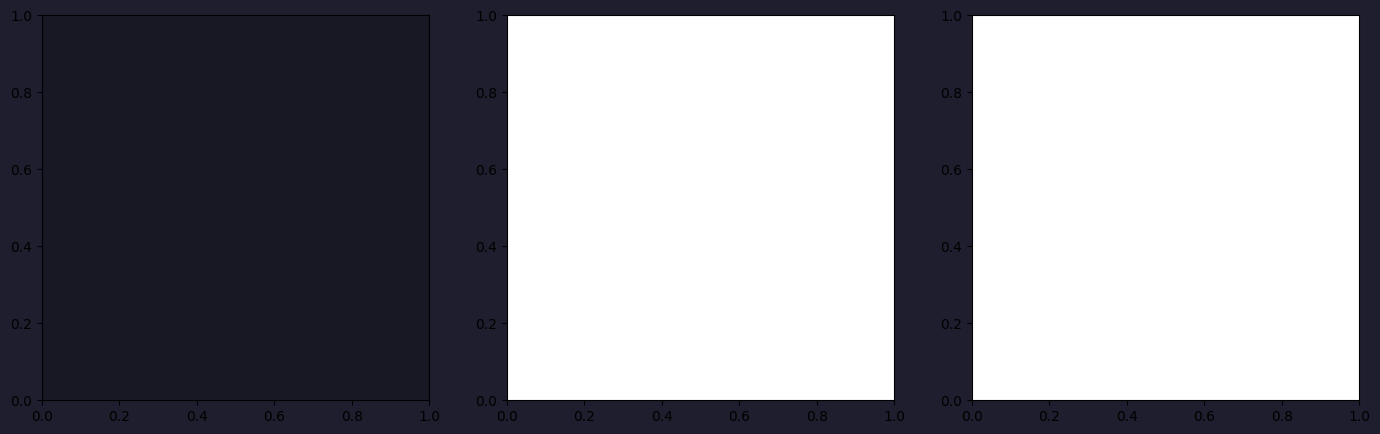

In [11]:
from sklearn.metrics import roc_curve, precision_recall_curve

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor('#1e1e2e')

# ── Panel 1: TNTComplEx training loss ─────────────────────────────────────────
ax = axes[0]
ax.set_facecolor('#181825')
ax.plot(loss_history, color='#89b4fa', lw=2)
ax.set_xlabel('Epoch', color='#cdd6f4')
ax.set_ylabel('Loss', color='#cdd6f4')
ax.set_title('TNTComplEx Training Loss', color='#cdd6f4')
ax.tick_params(colors='#cdd6f4')
for sp in ['top', 'right']: ax.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax.spines[sp].set_color('#313244')

# ── Panel 2: TNTComplEx — MRR per relation ────────────────────────────────────
ax2 = axes[1]
ax2.set_facecolor('#181825')
rel_labels = ['All', 'ASSIGNED\nTO', 'REQUIRES\nPERMIT']
mrr_vals   = [results_all['MRR'], results_assign['MRR'], results_reqperm['MRR']]
h1_vals    = [results_all['Hits@1'], results_assign['Hits@1'], results_reqperm['Hits@1']]
x = np.arange(len(rel_labels))
bars1 = ax2.bar(x - 0.2, mrr_vals, 0.35, label='MRR',    color='#89b4fa')
bars2 = ax2.bar(x + 0.2, h1_vals,  0.35, label='Hits@1', color='#a6e3a1')
ax2.set_xticks(x); ax2.set_xticklabels(rel_labels, color='#cdd6f4')
ax2.set_ylabel('Score', color='#cdd6f4')
ax2.set_title('TNTComplEx — Link Prediction\n(MRR and Hits@1 per relation)', color='#cdd6f4')
ax2.set_ylim(0, 1)
ax2.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=8)
ax2.tick_params(colors='#cdd6f4')
for sp in ['top', 'right']: ax2.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax2.spines[sp].set_color('#313244')
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, h + 0.01, f'{h:.2f}',
             ha='center', va='bottom', color='#cdd6f4', fontsize=7)

# ── Panel 3: TGN ROC curve ────────────────────────────────────────────────────
ax3 = axes[2]
ax3.set_facecolor('#181825')
try:
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    ax3.plot(fpr, tpr, color='#cba6f7', lw=2, label=f'TGN cert-aware (AUC={tgn_auc:.3f})')
    fpr_lr, tpr_lr, _ = roc_curve(y_te_np, lr_scores)
    ax3.plot(fpr_lr, tpr_lr, color='#a6e3a1', lw=1.5, linestyle='--',
             label=f'LogReg (AUC={lr_auc:.3f})')
    fpr_rf, tpr_rf, _ = roc_curve(y_te_np, rf_scores)
    ax3.plot(fpr_rf, tpr_rf, color='#fab387', lw=1.5, linestyle='--',
             label=f'RF (AUC={rf_auc:.3f})')
    ax3.plot([0, 1], [0, 1], color='#6c7086', linestyle=':', lw=1)
    ax3.set_xlabel('False Positive Rate', color='#cdd6f4')
    ax3.set_ylabel('True Positive Rate', color='#cdd6f4')
    ax3.set_title('TGN (cert-aware) — ROC Curve\nViolation Classification', color='#cdd6f4')
    ax3.legend(facecolor='#313244', labelcolor='#cdd6f4', fontsize=8)
except Exception as ex:
    ax3.text(0.5, 0.5, f'ROC N/A\n{ex}', ha='center', va='center', color='#cdd6f4')
ax3.tick_params(colors='#cdd6f4')
for sp in ['top', 'right']: ax3.spines[sp].set_visible(False)
for sp in ['bottom', 'left']: ax3.spines[sp].set_color('#313244')

plt.tight_layout()
plt.savefig(EXP_DIR / '8_tkg_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to experiments/UseCase4/8_tkg_models_comparison.png')

## 9. Summary — Model Comparison & Thesis Discussion

| Model | Task | Metric | Notes |
|---|---|---|---|
| **TNTComplEx** | Temporal link prediction | MRR / Hits@k | Natural fit: TKG with typed relations + bitemporal timestamps |
| **TGN (cert-aware)** | Violation classification | AUC-ROC / AP | Better with continuous event streams; now has correct features |
| **LogReg / RF** | Violation classification | AUC-ROC / AP | Static baselines — no temporal memory |

In [12]:
print('=' * 65)
print('UseCase4 — TKG Model Comparison Summary')
print('=' * 65)
print()
print('1. TNTComplEx — Temporal Link Prediction')
print(f'   All relations    MRR={results_all["MRR"]:.4f}  H@1={results_all["Hits@1"]:.4f}  '
      f'H@3={results_all["Hits@3"]:.4f}  H@10={results_all["Hits@10"]:.4f}')
print(f'   ASSIGNED_TO      MRR={results_assign["MRR"]:.4f}  H@1={results_assign["Hits@1"]:.4f}  '
      f'H@3={results_assign["Hits@3"]:.4f}  H@10={results_assign["Hits@10"]:.4f}')
print(f'   REQUIRES_PERMIT  MRR={results_reqperm["MRR"]:.4f}  H@1={results_reqperm["Hits@1"]:.4f}  '
      f'H@3={results_reqperm["Hits@3"]:.4f}  H@10={results_reqperm["Hits@10"]:.4f}')
print()
print('2. TGN (cert-aware) — Violation Classification')
print(f'   AUC-ROC: {tgn_auc:.4f} | Avg Precision: {tgn_ap:.4f}')
print(f'   LogReg:  AUC={lr_auc:.4f} | AP={lr_ap:.4f}')
print(f'   RF:      AUC={rf_auc:.4f} | AP={rf_ap:.4f}')
print()
print('DISCUSSION')
print('  TNTComplEx is the theoretically correct model for this dataset:')
print('  - Data is a structured TKG with typed relations')
print('  - Bitemporal timestamps (valid_time, tx_time) are native input')
print('  - Can model rule changes (REQUIRES_CERT at month 6)')
print('  - Interpretable: embedding distances reflect semantic similarity')
print()
print('  TGN (improved) is better for future continuous data:')
print('  - When events are frequent and continuous (sensor readings, logs)')
print('  - When worker assignment history matters for next prediction')
print('  - Adding cert-aware features fixed the main failure mode from nb 05')
print()
print('  Limitation: only 18 PERMIT_DENIED events (1.2%) — both models')
print('  are data-limited on the violation classification sub-task.')
print('  TNTComplEx frames it as link prediction which is more natural.')
print('=' * 65)

UseCase4 — TKG Model Comparison Summary

1. TNTComplEx — Temporal Link Prediction


NameError: name 'results_all' is not defined